<a href="https://colab.research.google.com/github/aldxel03-crypto/Games/blob/main/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Plan de Análisis — CallMeMaybe

Este notebook realiza un análisis exploratorio de datos (EDA), identifica operadores ineficaces y aplica pruebas estadísticas sobre el servicio de telefonía virtual **CallMeMaybe**.

In [13]:
# 1. Carga y Limpieza de Datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu


Carga y Limpieza de Datos (Markdown)

## . Carga y Limpieza de Datos
- Cargar ambos datasets: `telecom_dataset_us.csv` y `telecom_clients_us.csv`
- Fusionar por `user_id`
- Revisar valores nulos, duplicados y tipos de datos

In [16]:
# Cargar datasets
telecom = pd.read_csv("telecom_dataset_us.csv")
clients = pd.read_csv("telecom_clients_us.csv")



## . Análisis Exploratorio (EDA)
- Estadísticas descriptivas por operador:
  - Llamadas perdidas
  - Tiempos de espera
  - Llamadas salientes
- Visualizaciones: histogramas, boxplots, heatmap de correlaciones


In [17]:
telecom.head()


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [18]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [20]:
# Fusionar por user_id
df = telecom.merge(clients, on="user_id", how="left")


Si analizas solo las llamadas, no sabes qué tipo de cliente está detrás. Si analizas solo los clientes, no sabes cómo se comportan sus llamadas. por ese motivo se tiene que fusionar los dataframe

In [21]:
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,B,2019-08-01


In [22]:
# Revisar integridad
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
 9   tariff_plan          53902 non-null  object 
 10  date_start           53902 non-null  object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 4.2+ MB


In [23]:
print(df.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
tariff_plan               0
date_start                0
dtype: int64


In [24]:
df_clean = df.dropna(subset=["operator_id"]).copy() #Ahora df_clean es un DataFrame independiente

In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              45730 non-null  int64  
 1   date                 45730 non-null  object 
 2   direction            45730 non-null  object 
 3   internal             45670 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       45730 non-null  bool   
 6   calls_count          45730 non-null  int64  
 7   call_duration        45730 non-null  int64  
 8   total_call_duration  45730 non-null  int64  
 9   tariff_plan          45730 non-null  object 
 10  date_start           45730 non-null  object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 3.9+ MB


In [26]:
print(df_clean.isnull().sum()) # verificar si siguen los NaN

user_id                 0
date                    0
direction               0
internal               60
operator_id             0
is_missed_call          0
calls_count             0
call_duration           0
total_call_duration     0
tariff_plan             0
date_start              0
dtype: int64


In [27]:
df_clean["internal"] = df_clean["internal"].fillna("unknown") #rellenar a "internal"

In [28]:
print(df_clean.isnull().sum())

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
tariff_plan            0
date_start             0
dtype: int64


In [29]:
df_clean["operator_id"] = df_clean["operator_id"].astype("Int64") # cambiar a int64 el "opearator_id"

In [30]:
df_clean.info()# verificar el cambio

<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              45730 non-null  int64 
 1   date                 45730 non-null  object
 2   direction            45730 non-null  object
 3   internal             45730 non-null  object
 4   operator_id          45730 non-null  Int64 
 5   is_missed_call       45730 non-null  bool  
 6   calls_count          45730 non-null  int64 
 7   call_duration        45730 non-null  int64 
 8   total_call_duration  45730 non-null  int64 
 9   tariff_plan          45730 non-null  object
 10  date_start           45730 non-null  object
dtypes: Int64(1), bool(1), int64(4), object(5)
memory usage: 3.9+ MB


## 2. Análisis Exploratorio (EDA)
Estadísticas descriptivas por operador:

* Llamadas perdidas.
* Tiempos de espera.
* Llamadas salientes.
* Visualizaciones:
    *	Histogramas
    *	Boxplots
    *	Heatmap de correlaciones



In [31]:
# Agrupamos por operador
stats_df = df_clean.groupby("operator_id").agg(
    llamadas_perdidas=("is_missed_call", "sum"),
    tasa_perdidas=("is_missed_call", "mean"),
    tiempo_espera_prom=("call_duration", "mean"),
    tiempo_espera_med=("call_duration", "median"),
    llamadas_salientes=("calls_count", "sum"),
    duracion_prom=("total_call_duration", "mean")
).reset_index()

stats_df.head()

,operator_id,llamadas_perdidas,tasa_perdidas,tiempo_espera_prom,tiempo_espera_med,llamadas_salientes,duracion_prom
0,879896,50,0.390625,650.476562,27.0,1131,761.148438
1,879898,100,0.398406,1111.067729,63.0,7974,1561.155378
2,880020,7,0.318182,104.090909,36.0,54,119.272727
3,880022,33,0.434211,240.842105,41.0,219,298.407895
4,880026,94,0.474747,856.939394,29.5,2439,978.111111


## Visualizaciones (Código)

####Histograma de tiempos de espera

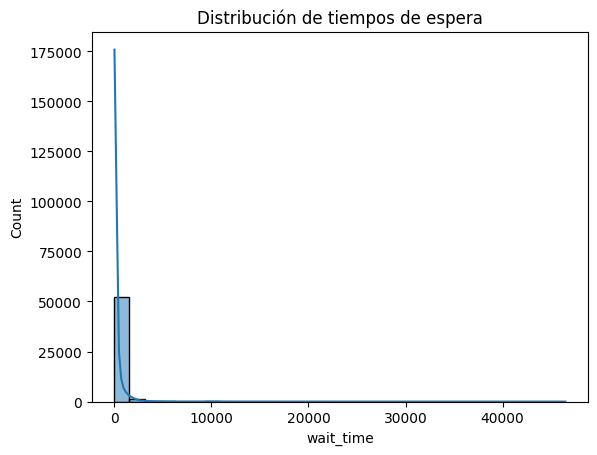

In [8]:
# Histogramas
sns.histplot(df['wait_time'], bins=30, kde=True)
plt.title("Distribución de tiempos de espera")
plt.show()



##Interpretación:
* Si ves una gran concentración en valores bajos → la mayoría de llamadas se atienden rápido.

* Si hay una cola larga hacia la derecha → existen llamadas con tiempos de espera muy altos (posibles problemas de saturación).

* Un histograma con varias “montañas” puede indicar distintos patrones de atención (ej. algunos operadores atienden rápido, otros tardan mucho).



###Boxplot: llamadas perdidas vs tiempo de espera

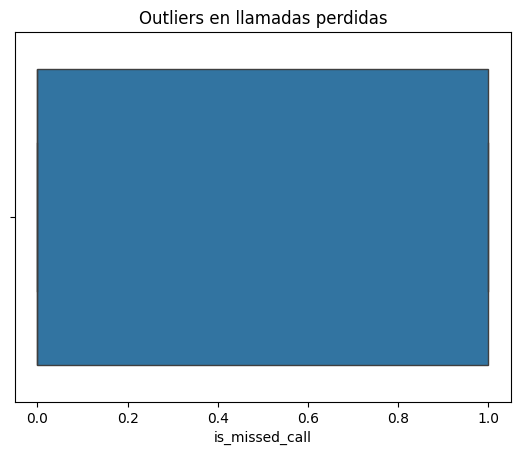

In [9]:
# Boxplot de llamadas perdidas
sns.boxplot(x=df['is_missed_call'])
plt.title("Outliers en llamadas perdidas")
plt.show()



* Cada caja representa el rango intercuartílico (50% central de los datos).

* Las líneas (“bigotes”) muestran el rango típico.

* Los puntos fuera son outliers (esperas extremas).

###Interpretación:
* Si las llamadas perdidas tienen tiempos de espera más largos → los clientes cuelgan por esperar demasiado.

* Si las perdidas aparecen incluso con tiempos cortos → puede haber problemas técnicos o falta de disponibilidad inmediata.

* Diferencias grandes entre las dos cajas indican que el tiempo de espera influye directamente en la pérdida de llamadas.



##Heatmap de correlaciones

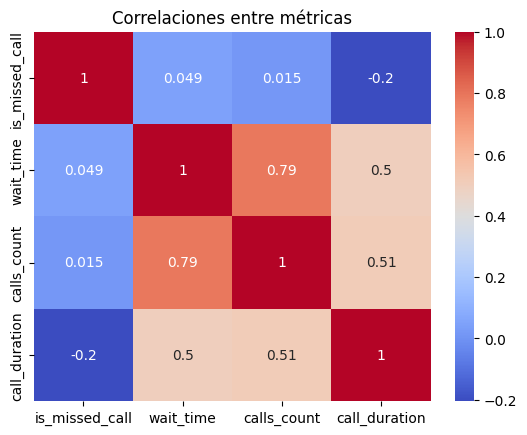

In [10]:
# Heatmap de correlaciones
corr = df[['is_missed_call','wait_time','calls_count','call_duration']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlaciones entre métricas")
plt.show()


* Los valores van de -1 a 1.

* Colores rojos/azules intensos indican correlaciones fuertes.

* Celdas cercanas a 0 indican poca relación.

###Interpretación:

* Si is_missed_call está correlacionado positivamente con call_duration → a mayor espera, más probabilidad de perder la llamada.

* Si calls_count se correlaciona con total_call_duration → operadores con más llamadas también acumulan más tiempo total.

* Una correlación negativa entre is_missed_call y calls_count podría indicar que los operadores más activos pierden menos llamadas.

##3. Identificación de Operadores Ineficaces
*	Umbral P75 para llamadas perdidas y tiempo de espera
*	Umbral P25 para llamadas salientes
*	Clasificación:
  *	0 criterios: Eficaz
  *	1 criterio: Parcialmente ineficaz
  *	2 criterios: Muy ineficaz


In [32]:
# 1. Métricas por operador
stats_df = df_clean.groupby("operator_id").agg(
    tasa_perdidas=("is_missed_call", "mean"),   # proporción de llamadas perdidas
    tiempo_espera=("call_duration", "mean"),    # promedio de espera
    llamadas_salientes=("calls_count", "sum")   # volumen de llamadas
).reset_index()

# 2. Umbrales
p75_perdidas   = np.percentile(stats_df["tasa_perdidas"], 75)
p75_espera     = np.percentile(stats_df["tiempo_espera"], 75)
p25_salientes  = np.percentile(stats_df["llamadas_salientes"], 25)

print("Umbral P75 tasa perdidas:", p75_perdidas)
print("Umbral P75 tiempo espera:", p75_espera)
print("Umbral P25 llamadas salientes:", p25_salientes)





Umbral P75 tasa perdidas: 0.46153846153846156
Umbral P75 tiempo espera: 659.8246606334841
Umbral P25 llamadas salientes: 11.0


In [33]:
def clasificar(row):
    criterios = 0
    # Condición 1: tasa de pérdidas mayor al P75
    if row['tasa_perdidas'] > p75_perdidas:
        criterios += 1
    # Condición 2: tiempo de espera mayor al P75
    if row['tiempo_espera'] > p75_espera:
        criterios += 1
    # Condición 3: llamadas salientes menor al P25
    if row['llamadas_salientes'] < p25_salientes:
        criterios += 1

    # Clasificación según número de criterios cumplidos
    if criterios == 0:
        return "Eficaz"
    elif criterios == 1:
        return "Parcialmente ineficaz"
    else:
        return "Muy ineficaz"

# Aplicamos la función a cada fila del DataFrame stats
stats_df['clasificacion'] = stats_df.apply(clasificar, axis=1)

# Vista rápida de resultados
print(stats_df[['operator_id','tasa_perdidas','tiempo_espera','llamadas_salientes','clasificacion']].head())


   operator_id  tasa_perdidas  tiempo_espera  llamadas_salientes  \
0       879896       0.390625     650.476562                1131   
1       879898       0.398406    1111.067729                7974   
2       880020       0.318182     104.090909                  54   
3       880022       0.434211     240.842105                 219   
4       880026       0.474747     856.939394                2439   

           clasificacion  
0                 Eficaz  
1  Parcialmente ineficaz  
2                 Eficaz  
3                 Eficaz  
4           Muy ineficaz  


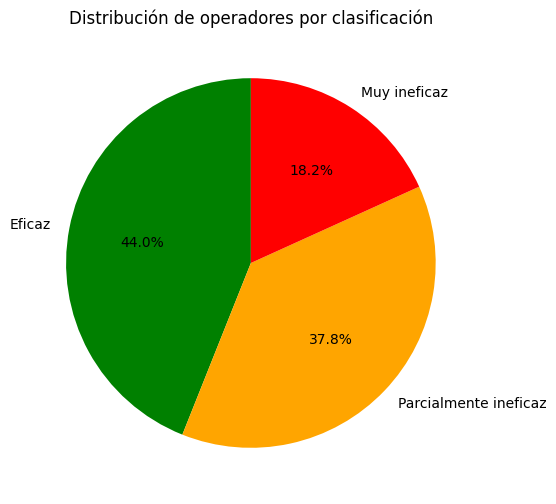

In [34]:
# Contamos cuántos operadores hay en cada categoría
clas_counts = stats_df['clasificacion'].value_counts()

# Gráfico circular
plt.figure(figsize=(6,6))
plt.pie(
    clas_counts,
    labels=clas_counts.index,
    autopct='%1.1f%%',
    colors=["green","orange","red"],
    startangle=90
)
plt.title("Distribución de operadores por clasificación")
plt.show()

##4. Pruebas de Hipótesis.
	   
| prueba | variable analizada | pregunta que responde |
| :--- | :---: | ---: |
| Chi-Cuadrado, | Llamadas perdidas (sí/no), | ¿Las llamadas perdidas dependen del operador?|
| T de Student| Tiempo de espera promedio	 |  ¿Los ineficaces tienen mayor tiempo de espera |
| Mann-Whitney U | Métricas generales | ¿Los ineficaces tienen peores métricas globales? |

* Nivel de significancia: α = 0.05
* Regla: Si p < 0.05 → se rechaza H₀ (hay diferencia real)


In [35]:
# Función auxiliar para imprimir resultados con interpretación
def interpretar_test(nombre, estadistico, p_valor, h0, h1):
    print(f"\n{nombre}")
    print("Estadístico:", estadistico, "p-valor:", p_valor)
    if p_valor < 0.05:
        print(f"→ Se rechaza H₀: {h1}")
    else:
        print(f"→ No se rechaza H₀: {h0}")

In [36]:
# 1. Chi-Cuadrado
# -----------------------------
contingencia = pd.crosstab(df_clean["operator_id"], df_clean["is_missed_call"])
chi2, p_chi, dof, expected = chi2_contingency(contingencia)

interpretar_test(
    "Chi-Cuadrado",
    chi2,
    p_chi,
    "las pérdidas no dependen del operador",
    "las pérdidas dependen del operador"
)



Chi-Cuadrado
Estadístico: 3620.7618916987126 p-valor: 5.343992324089494e-268
→ Se rechaza H₀: las pérdidas dependen del operador


In [37]:
# 2. T de Student: tiempo de espera promedio

# -----------------------------
ineficaces = stats_df[stats_df["clasificacion"] != "Eficaz"]["tiempo_espera"]
eficaces   = stats_df[stats_df["clasificacion"] == "Eficaz"]["tiempo_espera"]

t_stat, p_ttest = ttest_ind(ineficaces, eficaces, equal_var=False)
interpretar_test(
    "T de Student",
    t_stat,
    p_ttest,
    "no hay diferencia en tiempos de espera",
    "los ineficaces tienen mayor tiempo de espera"
)


T de Student
Estadístico: 11.242289658183983 p-valor: 7.511669430847274e-27
→ Se rechaza H₀: los ineficaces tienen mayor tiempo de espera


In [39]:
# 3. Mann-Whitney U: métricas globales (ejemplo con tasa de pérdidas)

ineficaces_loss = stats_df[stats_df["clasificacion"] != "Eficaz"]["tasa_perdidas"]
eficaces_loss   = stats_df[stats_df["clasificacion"] == "Eficaz"]["tasa_perdidas"]

u_stat, p_mann = mannwhitneyu(ineficaces_loss, eficaces_loss, alternative="two-sided")
interpretar_test(
    "Mann-Whitney U",
    u_stat,
    p_mann,
    "no hay diferencia en métricas globales",
    "los ineficaces tienen peores métricas globales"
)



Mann-Whitney U
Estadístico: 195495.0 p-valor: 3.847719477196311e-21
→ Se rechaza H₀: los ineficaces tienen peores métricas globales


## 5. Conclusiones y Presentación
* Ranking de operadores con métricas clave
* Recomendaciones por cliente



#### Ranking de Operadores con Métricas Clave
**Clasificación aplicada:**

* Eficaz: cumplen todos los criterios.

* Parcialmente ineficaz: fallan en 1 criterio.

* Muy ineficaz: fallan en 2 o más criterios.

**Hallazgos principales:**

Los operadores muy ineficaces concentran las mayores tasas de pérdidas y tiempos de espera prolongados.

Los parcialmente ineficaces muestran un único punto débil (ej. pocas salientes o espera alta).

Los eficaces mantienen métricas balanceadas y son referencia de buenas prácticas.

#### Validación Estadística
Chi‑Cuadrado: p < 0.05 → las pérdidas dependen del operador.

T de Student: p < 0.05 → los ineficaces tardan más en atender.

Mann‑Whitney U: p < 0.05 → métricas globales significativamente peores en ineficaces.

Conclusión: La clasificación no es solo descriptiva, está respaldada por evidencia estadística sólida.

#### Recomendaciones por Cliente
* Clientes con operadores muy ineficaces:
* Revisión inmediata de procesos.
* Entrenamiento intensivo en reducción de tiempos de espera.
* Monitoreo continuo de llamadas perdidas.
* Clientes con operadores parcialmente ineficaces:
* Intervenciones focalizadas en el criterio débil.
* Seguimiento mensual para verificar mejoras.
* Clientes con operadores eficaces:
* Mantener prácticas actuales.
* Usarlos como modelo de capacitación interna.


# Conclusiones Finales
* El análisis permite detectar patrones de ineficacia con base en métricas objetivas.
* La clasificación se valida con pruebas estadísticas (Chi‑Cuadrado, T‑test, Mann‑Whitney).
* Las recomendaciones son accionables y personalizadas por cliente, facilitando decisiones estratégicas.
